<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Patricia González Todd

 A continuación, presento el código para la generación de senoidales, se puede ver en un principio la definición de funcións que generan los valores de una senoidal en nn muestras, una sin ruido ruido y otra con ruido, esto me permitió llegar a dos señales que puedo comparar al ser graficadas. 


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_funcion_sen_ruido(vmax, dc, ff, ph, nn, fs, snr, pr):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    desvio = np.sqrt(pr)
    r = np.random.normal(0, desvio, len(tt)) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
    print(f"Potencia de ruido (pr): {pr}") # esto es la potencia de ruido
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    xx1 = xx + r
    return tt, xx1


Posteriormente defino los parámetros y llamo a las funciones para luego graficar la comparación, bajo esto se imprimirá el valor de la potencia de ruido que verifica las cuentas hechas en la estimación.

In [20]:
# Parámetros
A = 1 
dc = 0
fs = 1000
ff = 1
fase = 0
muestras = 1000
snr = 20 #db
Ps = (A**2)/ 2
pr = Ps / (10**(snr/10)) #ESTO DEBERIA SER LA VARIANZA

# Llamadas a las funciones
tt, xx = mi_funcion_sen(A, dc, ff, fase, muestras, fs)
tt1, xx1 = mi_funcion_sen_ruido(A, dc, ff, fase, muestras, fs, snr, pr)


Potencia de ruido (pr): 0.005


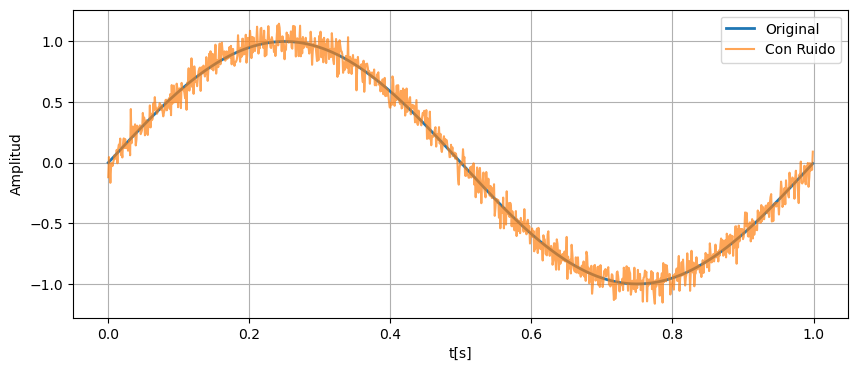

In [24]:
# Gráfico
plt.figure(figsize=(10, 4))

plt.plot(tt, xx, label="Original", linewidth=2)
plt.plot(tt1, xx1, label="Con Ruido", alpha=0.7)

plt.xlabel("t[s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()

#### EXPERIMENTO DE ALIASING (BONUS)

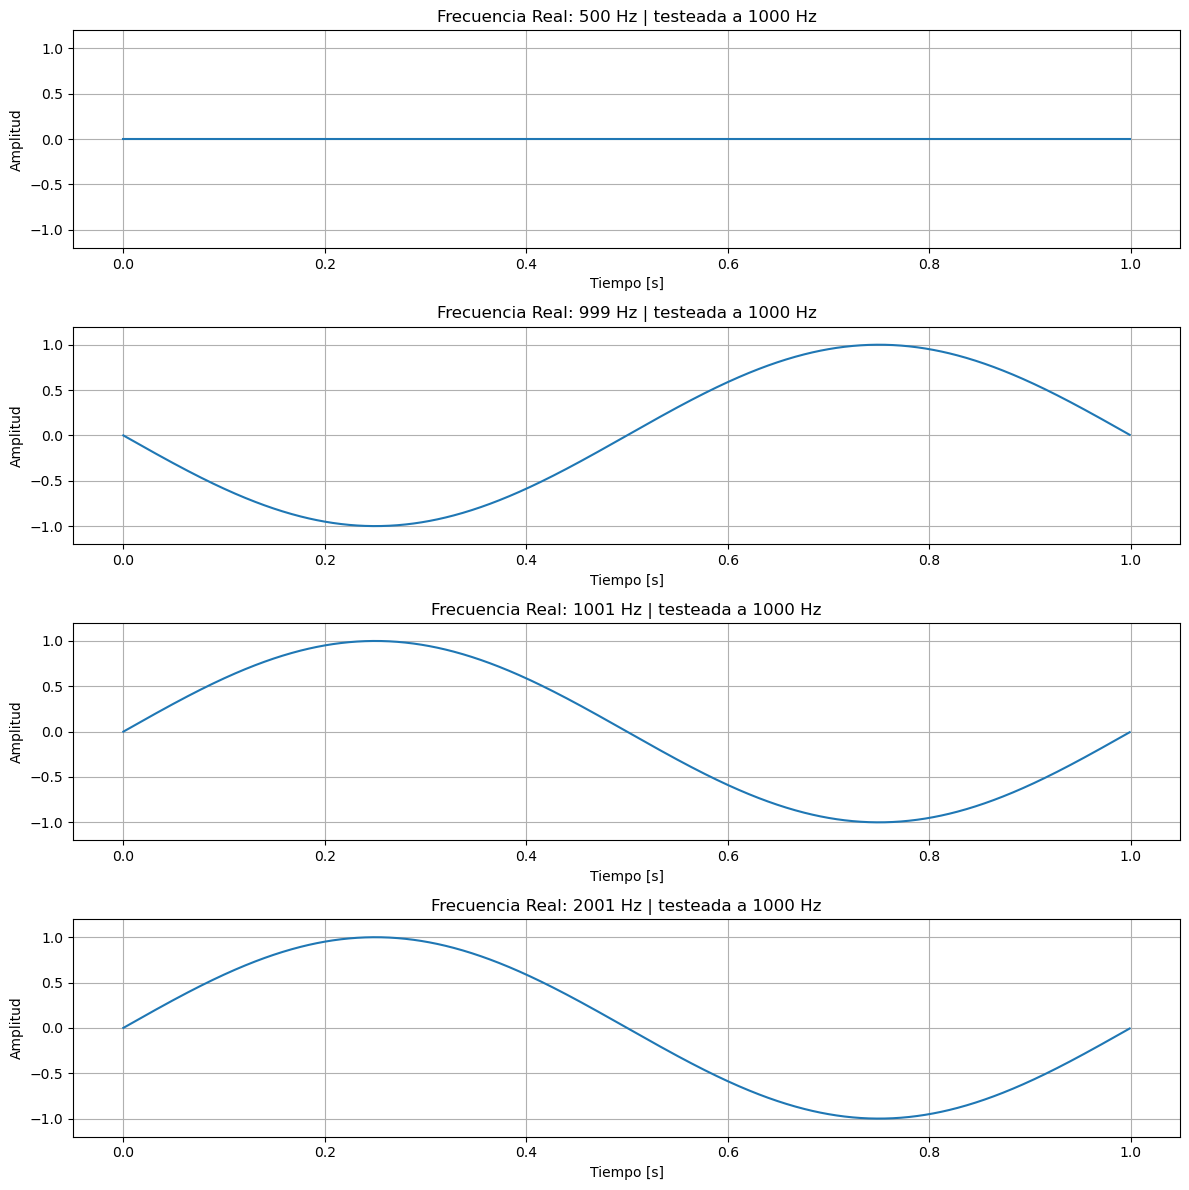

In [25]:
#%% Experimento aliasing
# Parámetros base
fs_bonus = 1000  
frecuencias_test = [500, 999, 1001, 2001] 

# Figura con 4 sub-gráficos (uno arriba del otro)
plt.figure(figsize=(12, 12))

for i, ff in enumerate(frecuencias_test):

    t, x = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn = muestras, fs = fs)
    
    # Gráfico cuadruple, cada uno en una fila
    plt.subplot(4, 1, i+1) #Esta linea solo funciona en jupyter
    plt.plot(t, x)
    
    # Diseño de gráfico
    plt.title(f"Frecuencia Real: {ff} Hz | testeada a {fs} Hz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    #plt.xlim([0, 0.1]) # Hacemos zoom en los primeros 0.1s para ver la forma
    plt.ylim([-1.2, 1.2])

plt.tight_layout() # Para que no se amontonen los títulos
plt.show()

##### EXPLICACIÓN DE LOS RESULTADOS

1. En 500 Hz: Estamos en el límite de Nyquist. Se ve la frecuencia correcta pero con pocos puntos.
2. En 999 Hz: Se produce Aliasing. La señal se 'disfraza' de una frecuencia de 1 Hz.
3. En 1001 Hz: Al superar la frecuencia de muestreo, la señal se solapa y vuelve a verse como 1 Hz.
4. En 2001 Hz: Es un múltiplo de fs, por lo que la diferencia vuelve a ser 1 Hz y se ve igual a las anteriores.

**Moraleja**: Si la frecuencia de la señal es mayor a la mitad de fs (500Hz), la información se pierde o se deforma.")
